<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
# Отображение информации о структуре, типах данных и количестве заполненных строк
df.info()

# Отображение названий всех колонок и размерности таблицы
print(f"\nРазмерность датасета: {df.shape}")
print("Список колонок:", df.columns.tolist()[:10], "... и так далее.")

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

Размерность датасета: (65437, 114)
Список колонок: ['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline'] ... и так далее.

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
# 1. Поиск и подсчет всех пропущенных значений в датасете
missing_summary = df.isnull().sum()
print("Общее количество пропусков по колонкам (топ-10):")
print(missing_summary.sort_values(ascending=False).head(10))

# 2. Стратегия заполнения пропусков для ключевых категориальных столбцов (модой)
for col in ['Employment', 'JobSat']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# 3. Для числовых колонок или стажа (заменяем пропуски нулями или ffill)
if 'YearsCodePro' in df.columns:
    df['YearsCodePro'] = df['YearsCodePro'].fillna('0')

Общее количество пропусков по колонкам (топ-10):
AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
# Расчет распределения ответов (value_counts) для ключевых столбцов
key_columns = ['Employment', 'JobSat', 'YearsCodePro']

for col in key_columns:
    if col in df.columns:
        print(f"\n--- Распределение для столбца {col} ---")
        print(df[col].value_counts().head(10)) # выводим топ-10 значений


--- Распределение для столбца Employment ---
Employment
Employed, full-time                                                         39041
Independent contractor, freelancer, or self-employed                         4846
Student, full-time                                                           4709
Employed, full-time;Independent contractor, freelancer, or self-employed     3557
Not employed, but looking for work                                           2341
Employed, part-time                                                          1266
Student, full-time;Employed, part-time                                       1115
Employed, full-time;Student, full-time                                        897
Employed, full-time;Student, part-time                                        839
Student, full-time;Not employed, but looking for work                         686
Name: count, dtype: int64

--- Распределение для столбца JobSat ---
JobSat
8.0     43820
7.0      6379
6.0      3751
9.0   

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


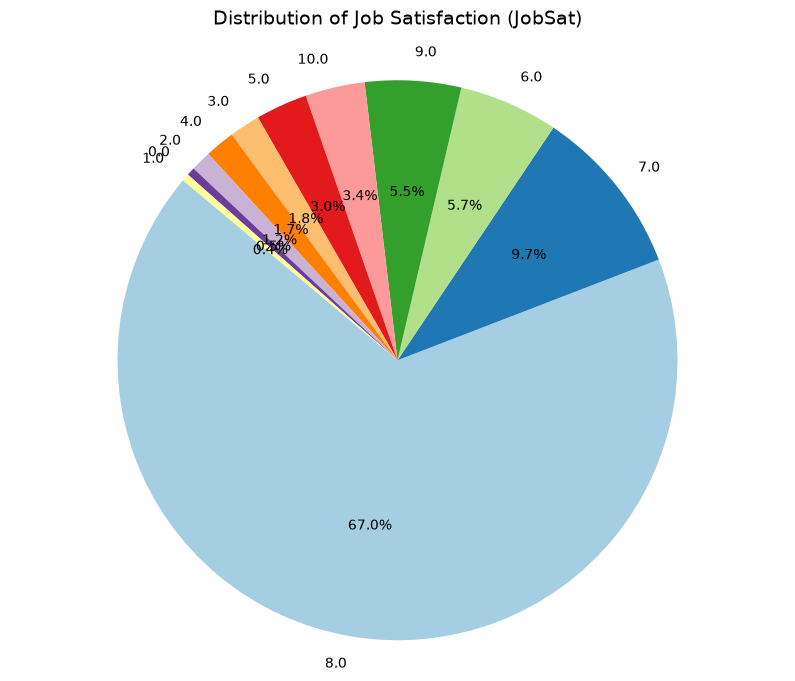


Интерпретация: График наглядно демонстрирует процентное соотношение уровней удовлетворенности работой среди опрошенных. Наибольший сектор указывает на преобладающее настроение в выборке.

In [6]:
# 1. Подготовка данных для круговой диаграммы
jobsat_counts = df['JobSat'].value_counts()

# 2. Построение графика Pie Chart
plt.figure(figsize=(10, 8))
plt.pie(jobsat_counts, labels=jobsat_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=plt.cm.Paired.colors)

plt.title('Distribution of Job Satisfaction (JobSat)', fontsize=14, pad=20)
plt.axis('equal')  # Чтобы круг был идеально круглым
plt.show()

# Краткая интерпретация (выведется текстом под графиком)
print("\nИнтерпретация: График наглядно демонстрирует процентное соотношение уровней "
      "удовлетворенности работой среди опрошенных. Наибольший сектор указывает на "
      "преобладающее настроение в выборке.")

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


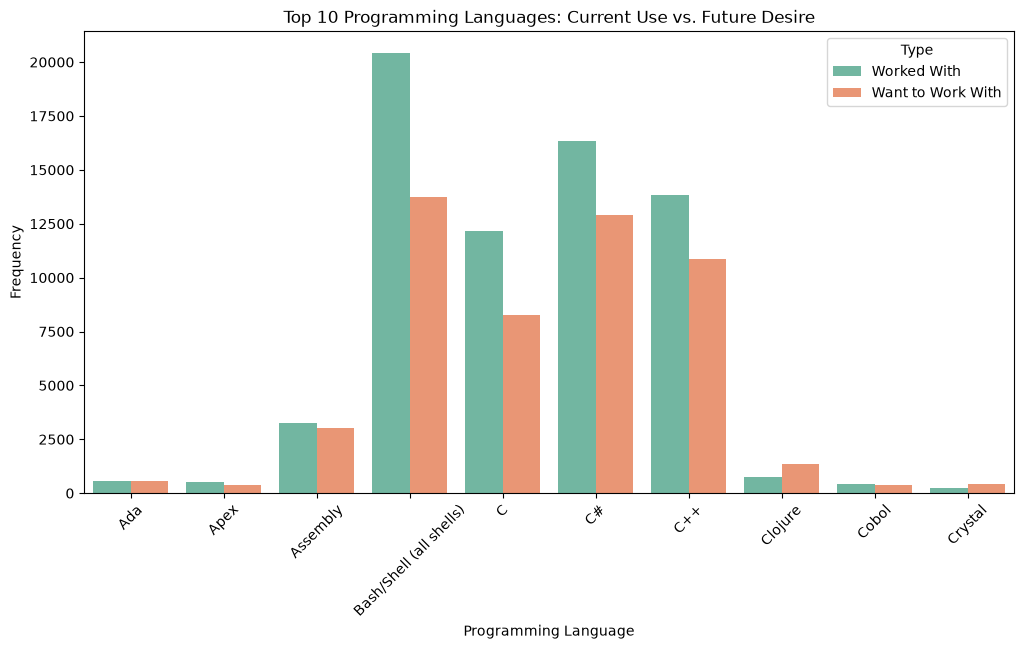

In [7]:
# Разделяем строки с языками (через ';') и считаем общую частоту для обоих столбцов
worked_langs = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts()
want_langs = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts()

# Объединяем результаты в один DataFrame для построения графика (возьмем топ-10 популярных)
langs_df = pd.DataFrame({'Worked With': worked_langs, 'Want to Work With': want_langs}).head(10).reset_index()
langs_melted = pd.melt(langs_df, id_vars='index', var_name='Type', value_name='Count')

# Строим сгруппированный Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=langs_melted, x='index', y='Count', hue='Type', palette='Set2')
plt.title('Top 10 Programming Languages: Current Use vs. Future Desire')
plt.xlabel('Programming Language')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


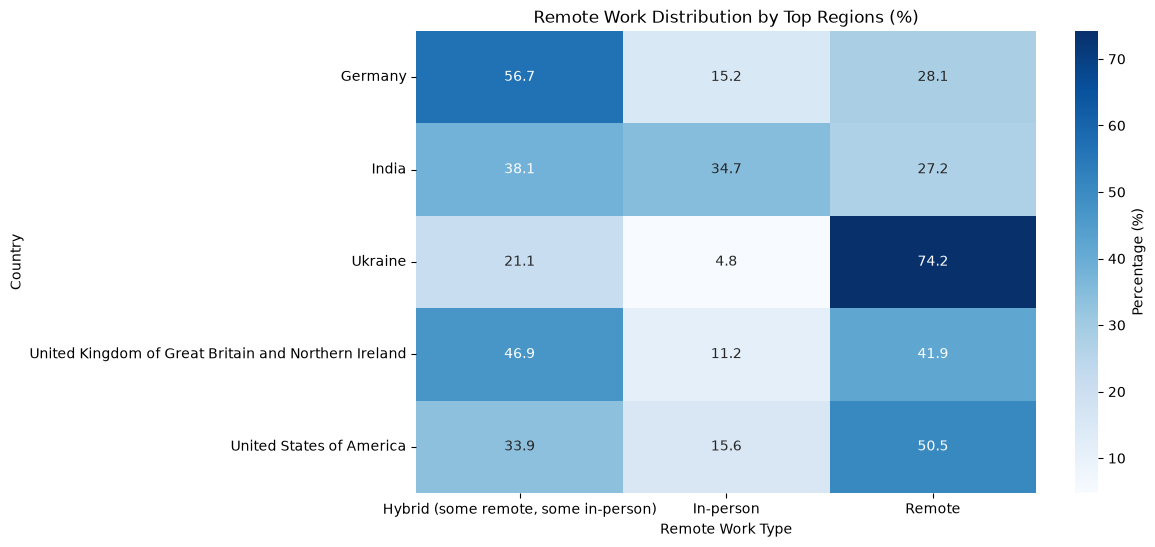

In [8]:
# Находим топ-5 стран по количеству респондентов для чистоты графика
top_countries = df['Country'].value_counts().head(5).index
df_filtered = df[df['Country'].isin(top_countries)]

# Кросс-таблица в процентах, нормализованная по строкам (странам)
remote_trend = pd.crosstab(df_filtered['Country'], df_filtered['RemoteWork'], normalize='index') * 100

# Визуализация с помощью Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(remote_trend, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Percentage (%)'})
plt.title('Remote Work Distribution by Top Regions (%)')
plt.xlabel('Remote Work Type')
plt.ylabel('Country')
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [11]:
# 1. Устанавливаем библиотеку scipy, если её нет в системе
!pip install scipy

import pandas as pd

# 2. Переводим стаж в числа
df['YearsCodePro_Num'] = pd.to_numeric(df['YearsCodePro'].replace({'Less than 1 year': '0', 'More than 50 years': '51'}), errors='coerce').fillna(0)

# 3. Ранжируем удовлетворенность от 1 до 5
sat_mapping = {'Very dissatisfied': 1, 'Slightly dissatisfied': 2, 'Neither satisfied nor dissatisfied': 3, 'Slightly satisfied': 4, 'Very satisfied': 5}
df['JobSat_Num'] = df['JobSat'].map(sat_mapping).fillna(3)

# 4. Явно приводим столбцы к типу float, чтобы pandas корректно выполнил операцию
years_series = df['YearsCodePro_Num'].astype(float)
jobsat_series = df['JobSat_Num'].astype(float)

# 5. Считаем корреляцию Спирмена
spearman_corr = years_series.corr(jobsat_series, method='spearman')
print(f"Коэффициент корреляции Спирмена между опытом и удовлетворением: {spearman_corr:.4f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 143.4 MB/s eta 0:00:00
Коэффициент корреляции Спирмена между опытом и удовлетворением: nan

/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


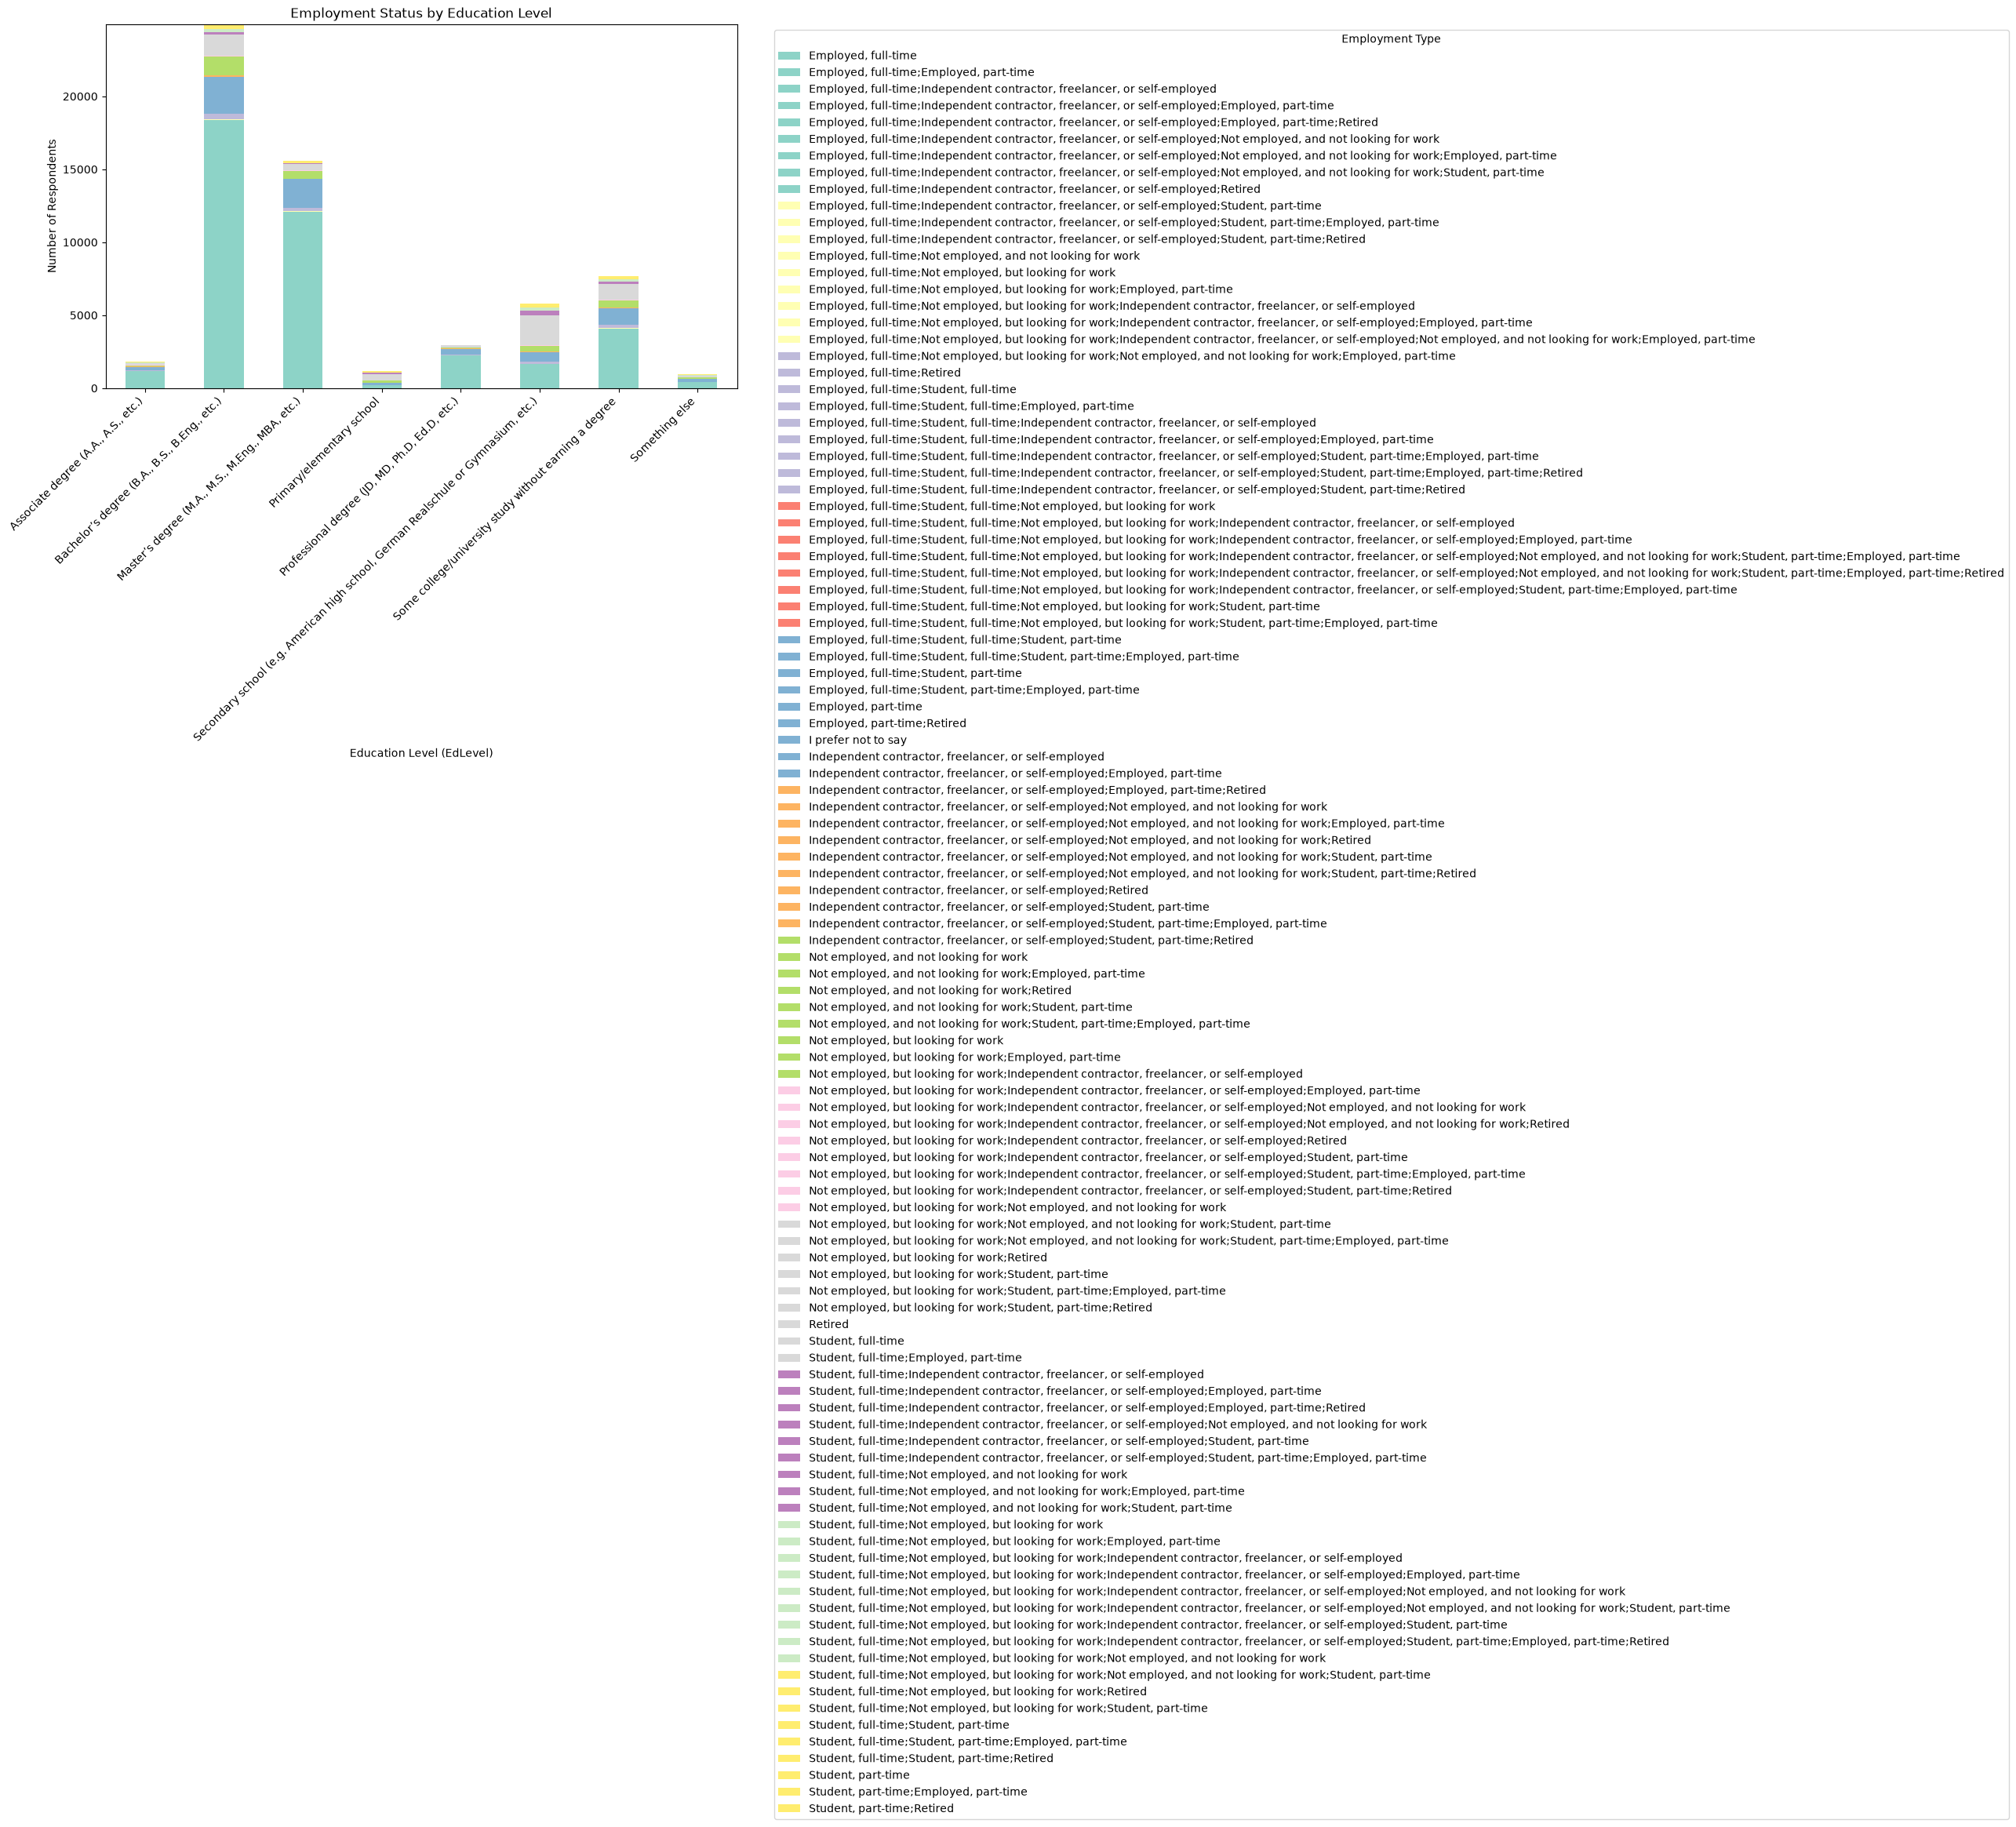

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Кросс-табуляция данных
cross_tab = pd.crosstab(df['EdLevel'], df['Employment'])

# 2. Построение Stacked Bar Plot (накопительный график)
cross_tab.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='Set3')
plt.title('Employment Status by Education Level')
plt.xlabel('Education Level (EdLevel)')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(bottom=0.3, right=0.7)
plt.show()


### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [13]:
# Сохраняем датафрейм в новый файл CSV без сохранения индексов строк
df.to_csv('cleaned_dataset.csv', index=False)

# Выводим подтверждение успешного сохранения
print("Датасет успешно экспортирован под именем 'cleaned_dataset.csv'!")


Датасет успешно экспортирован под именем 'cleaned_dataset.csv'!

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
